# Data Preprocessing & Exploratory Data Analysis

## Setup

In [4]:

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)


In [5]:

PROJECT_ROOT = Path().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_PATH = DATA_DIR / "raw" / "bank-additional-full.csv"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

RAW_DATA_PATH


PosixPath('/Users/janmeet/Desktop/SFU/FALL 2025/CMPT 459/Project/fall2025_cmpt459_d1_group7/data/raw/bank-additional-full.csv')

## Load Data

In [6]:

df = pd.read_csv(RAW_DATA_PATH, sep=';')
display(df.head())
display(df.shape)
df.info()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


(41188, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

**Key Insights:**
- There are 41,188 records in the dataset.
- There are 21 columns (features).
- 5 continuous numeric variables.
- 5 discrete numeric variables.
- 11 categorical variables.
- The last column y is the target variable, representing whether the client subscribed.


In [ ]:

overview = (
    pd.DataFrame({
        "dtype": df.dtypes,
        "n_unique": df.nunique(),
        "num_missing": df.isna().sum(),
    })
    .sort_index()
)
overview


,dtype,n_unique,num_missing
age,int64,78,0
campaign,int64,42,0
cons.conf.idx,float64,26,0
cons.price.idx,float64,26,0
contact,object,2,0
day_of_week,object,5,0
default,object,3,0
duration,int64,1544,0
education,object,8,0
emp.var.rate,float64,10,0


## Missing / 'unknown' Value Profiling

The raw dataset does not use NaN for all missing information. Instead, many categorical fields use the string `'unknown'` to mean "not provided".  
Before we transform the data, we quantify how often each column is missing or marked as `'unknown'`. This lets us justify our imputation strategy later.

In [5]:
missing_like_counts = {}

for col in df.columns:
    # actual NaN
    na_count = df[col].isna().sum()

    # placeholder "unknown" (only makes sense for object / categorical columns)
    unknown_count = (
        (df[col] == "unknown").sum()
        if df[col].dtype == "object"
        else 0
    )

    total_missing_like = na_count + unknown_count
    pct_missing_like = 100 * total_missing_like / len(df)

    missing_like_counts[col] = {
        "na_count": na_count,
        "unknown_count": unknown_count,
        "total_missing_like": total_missing_like,
        "pct_missing_like": pct_missing_like,
        "dtype": df[col].dtype,
        "n_unique": df[col].nunique()
    }

missing_like_df = (
    pd.DataFrame(missing_like_counts)
      .T
      .sort_values("pct_missing_like", ascending=False)
)

display(missing_like_df.head(10))

,na_count,unknown_count,total_missing_like,pct_missing_like,dtype,n_unique
default,0,8597,8597,20.872584,object,3
education,0,1731,1731,4.20268,object,8
housing,0,990,990,2.403613,object,3
loan,0,990,990,2.403613,object,3
job,0,330,330,0.801204,object,12
marital,0,80,80,0.194231,object,4
age,0,0,0,0.0,int64,78
poutcome,0,0,0,0.0,object,3
nr.employed,0,0,0,0.0,float64,11
euribor3m,0,0,0,0.0,float64,316


**Key Insights:**

- The dataset does not initially contain any true `NaN` values, but several categorical columns use `'unknown'` as a placeholder.
- The most affected features are:
  - `default` (≈21% missing-like),
  - `education` (≈4%),
  - `housing` and `loan` (≈2–3% each).
- These are important business variables. Dropping all rows with `'unknown'` would remove over 20% of the data.
- Therefore, in the next step we replace `'unknown'` with actual `NaN` values and later apply appropriate imputation (median for numerical features, most frequent for categorical features) instead of deleting rows.

## Handle Placeholder Missing Values

In [6]:

df_clean = df.copy()
categorical_cols = df_clean.select_dtypes(include="object").columns.tolist()
df_clean[categorical_cols] = df_clean[categorical_cols].replace("unknown", np.nan)

categorical_features = [col for col in categorical_cols if col != "y"]
numeric_features_raw = df_clean.select_dtypes(include="number").columns.tolist()

missing_counts = df_clean.isna().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]


default      8597
education    1731
housing       990
loan          990
job           330
marital        80
dtype: int64

In [7]:

total_rows = len(df_clean)
duplicate_count = df_clean.duplicated().sum()
duplicate_pct = duplicate_count / total_rows * 100

print(f"Total rows: {total_rows}")
print(f"Duplicate rows: {duplicate_count} ({duplicate_pct:.2f}%)")

if not missing_counts[missing_counts > 0].empty:
    missing_summary = missing_counts[missing_counts > 0].sort_values(ascending=False)
    print("\nColumns with missing values after replacing 'unknown':")
    for col, count in missing_summary.items():
        pct = count / total_rows * 100
        print(f"- {col}: {count} rows ({pct:.2f}%)")
else:
    print("No missing values detected after cleaning 'unknown' placeholders.")


Total rows: 41188
Duplicate rows: 12 (0.03%)

Columns with missing values after replacing 'unknown':
- default: 8597 rows (20.87%)
- education: 1731 rows (4.20%)
- housing: 990 rows (2.40%)
- loan: 990 rows (2.40%)
- job: 330 rows (0.80%)
- marital: 80 rows (0.19%)


**Key Insights:**

- Duplicate rows are counted and reported above. We consider removing them if the percentage is non-trivial.
- Missing values stem from the original `'unknown'` placeholders. Now pandas treat them as real nulls for further analysis. 
- Imputation choices (median for numeric, most frequent for categorical) are applied in the preprocessing pipeline below.


## Target Distribution

In [8]:

target_distribution = (
    df_clean["y"].value_counts().rename_axis("subscription").reset_index(name="count")
)
target_distribution["percentage"] = target_distribution["count"] / target_distribution["count"].sum() * 100

target_distribution


,subscription,count,percentage
0,no,36548,88.734583
1,yes,4640,11.265417


**Class Imbalance**
- The target variable (`y`) is clearly imbalanced around **89% "no"** vs **11% "yes"**.  
- This imbalance can bias the classifier toward predicting the majority class

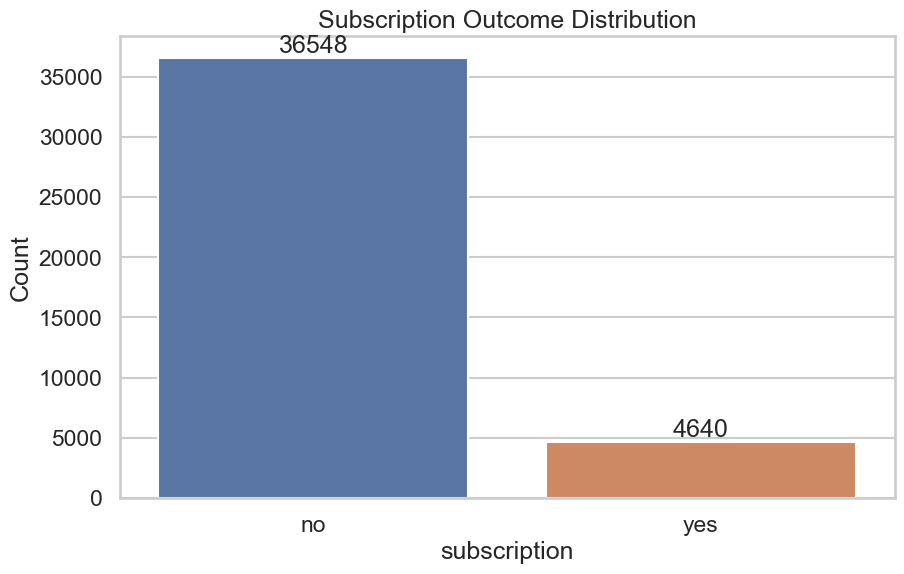

In [9]:

fig, ax = plt.subplots()
sns.barplot(data=target_distribution, x="subscription", y="count", hue="subscription", palette="deep", ax=ax)
ax.set_title("Subscription Outcome Distribution")
ax.set_ylabel("Count")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.show()


## Numeric Feature Distributions

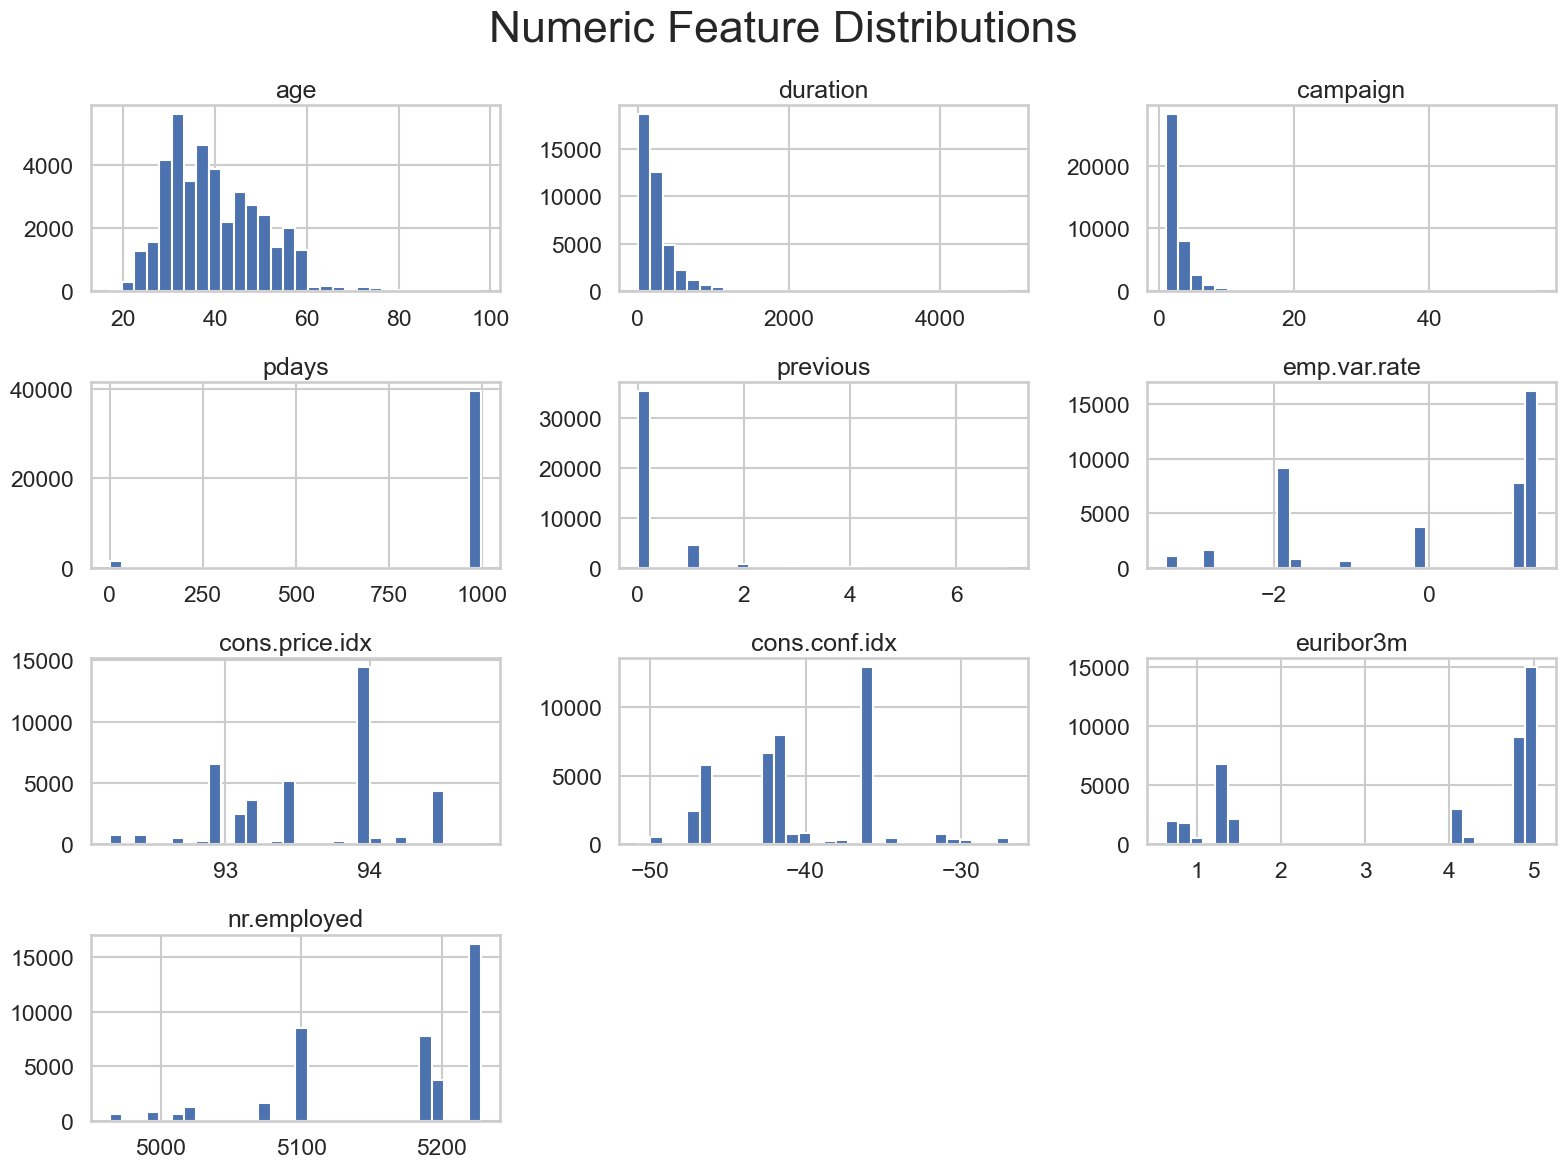

In [10]:

df_clean[numeric_features_raw].hist(bins=30, figsize=(16, 12))
plt.suptitle("Numeric Feature Distributions", fontsize=32)
plt.tight_layout()
plt.show()


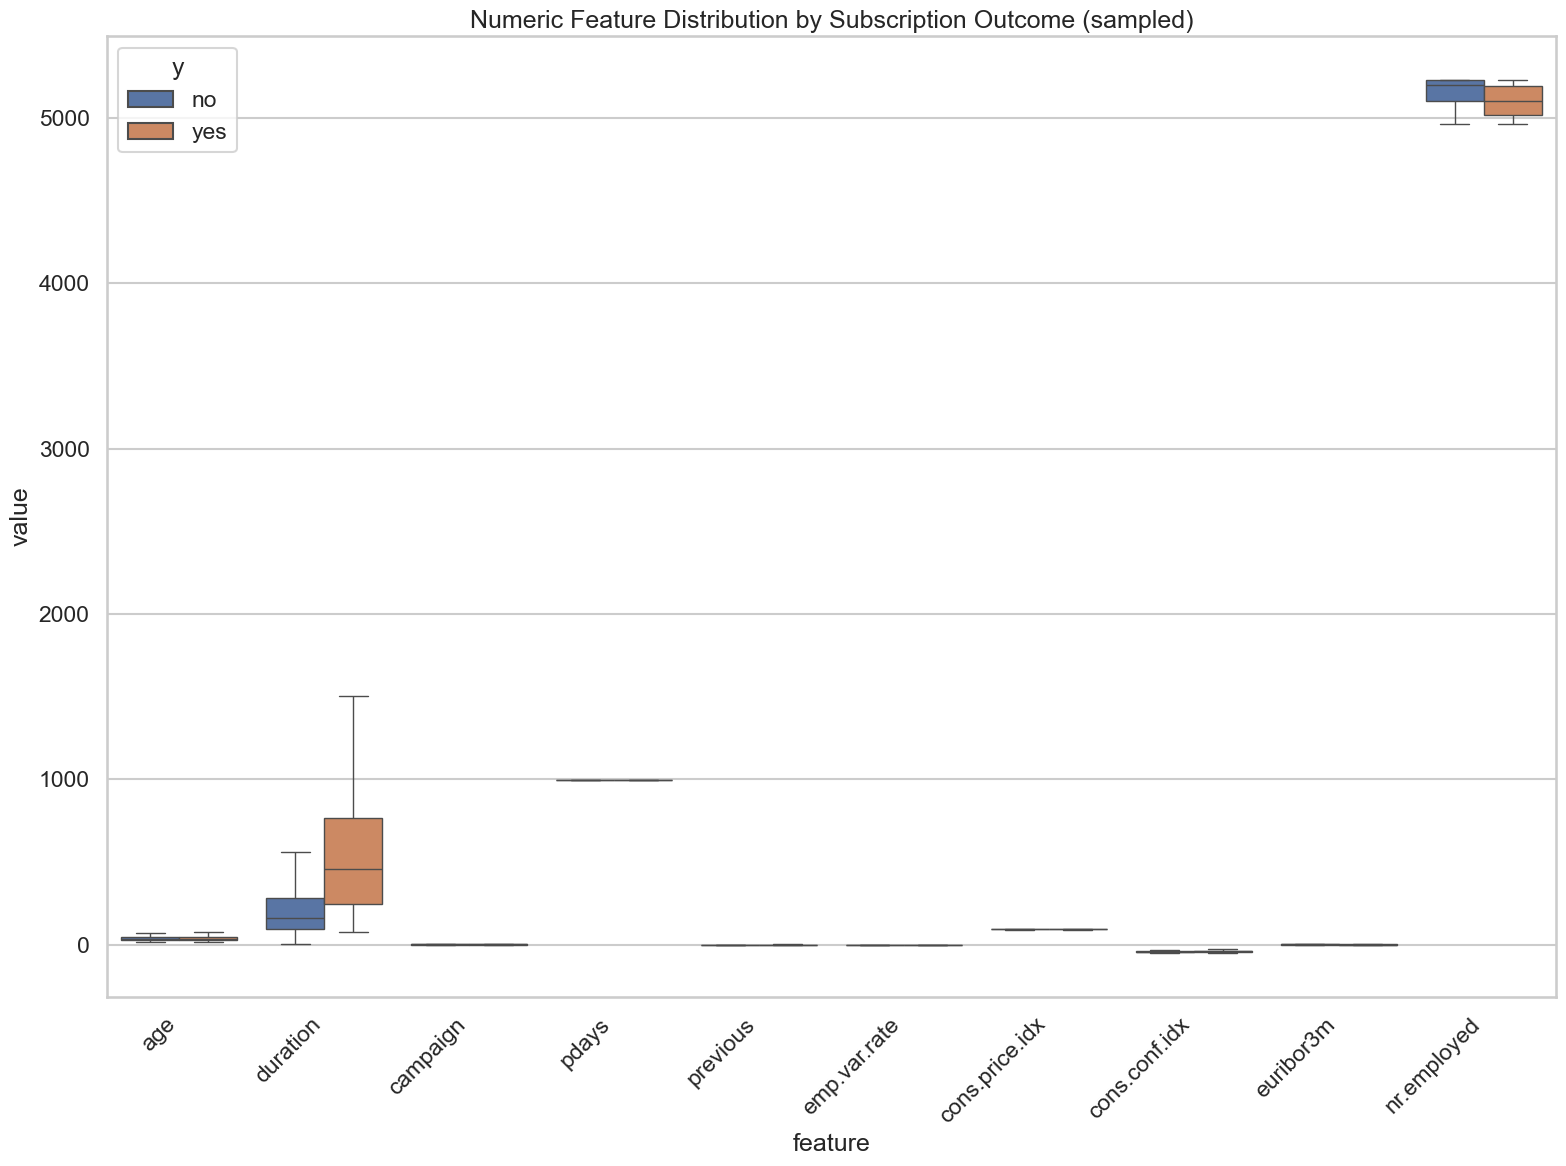

In [11]:

sampled = df_clean.sample(n=5000, random_state=42) if len(df_clean) > 5000 else df_clean
melted = sampled.melt(id_vars="y", value_vars=numeric_features_raw, var_name="feature", value_name="value")

plt.figure(figsize=(16, 12))
sns.boxplot(data=melted, x="feature", y="value", hue="y", showfliers=False)
plt.xticks(rotation=45, ha="right")
plt.title("Numeric Feature Distribution by Subscription Outcome (sampled)")
plt.tight_layout()
plt.show()


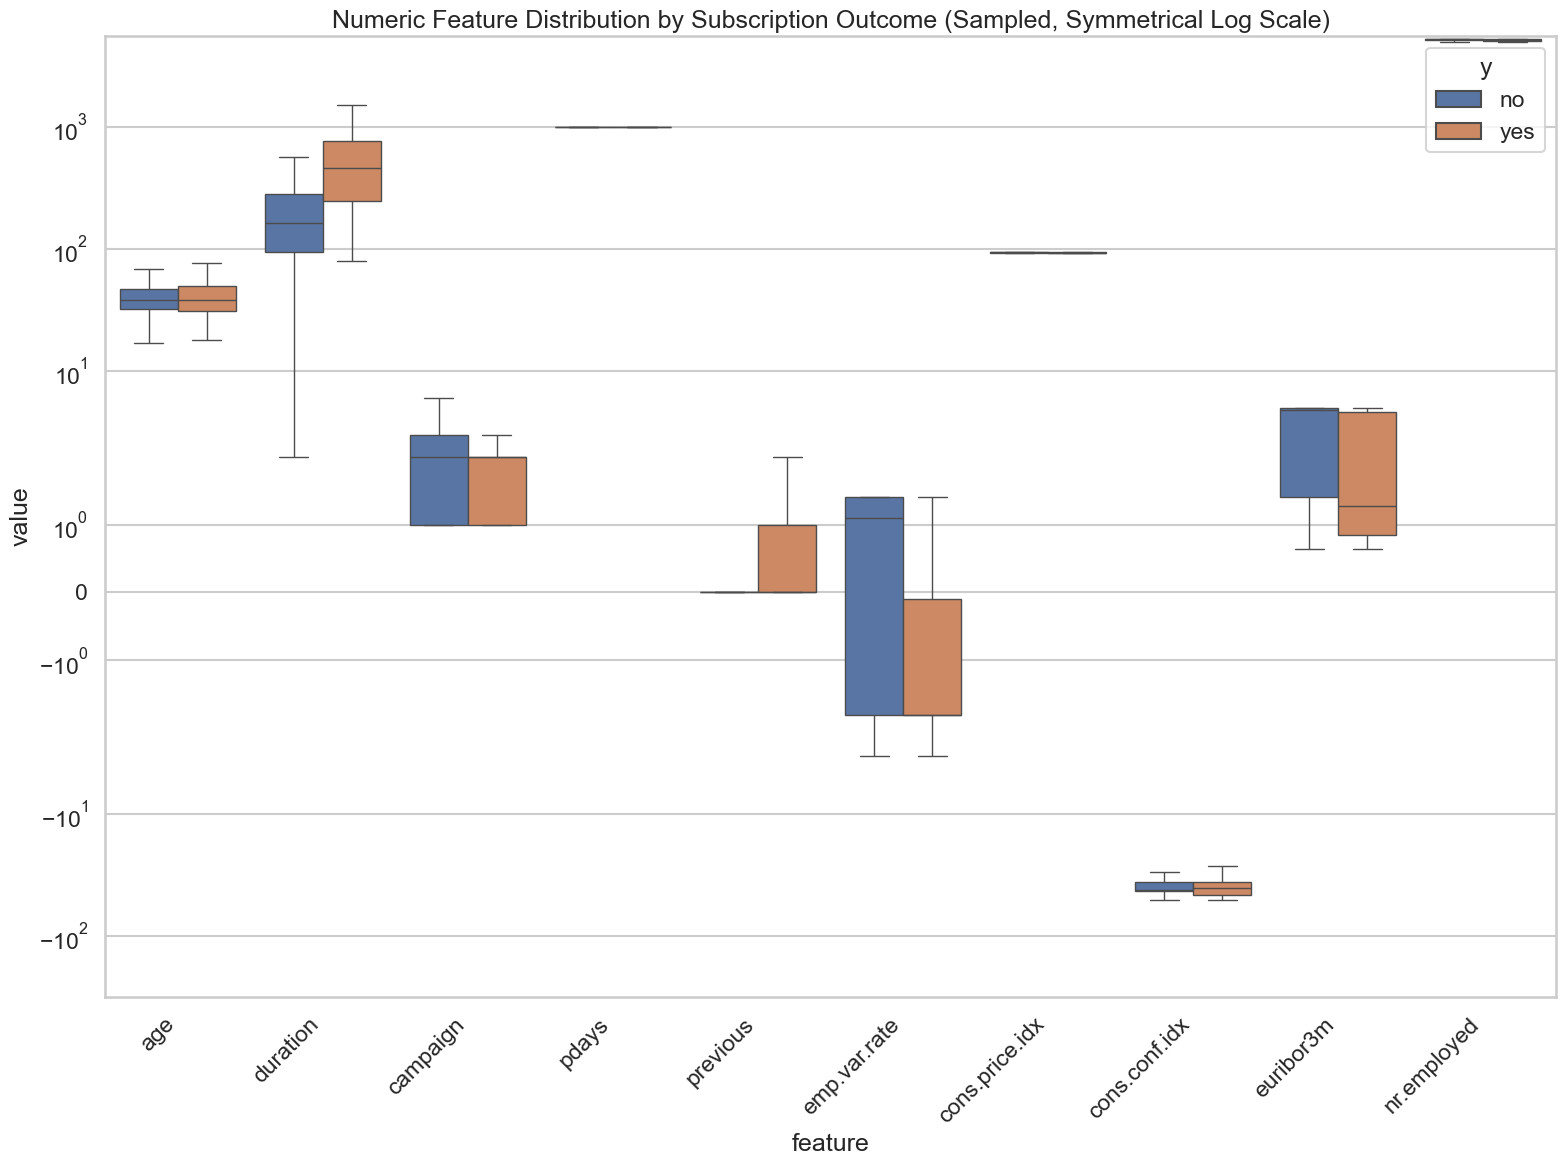

In [12]:
# Symmetrical log scale
sampled = df_clean.sample(n=5000, random_state=42) if len(df_clean) > 5000 else df_clean
melted = sampled.melt(id_vars="y", value_vars=numeric_features_raw, var_name="feature", value_name="value")

plt.figure(figsize=(16, 12))
sns.boxplot(data=melted, x="feature", y="value", hue="y", showfliers=False)
plt.yscale("symlog") 
plt.xticks(rotation=45, ha="right")
plt.title("Numeric Feature Distribution by Subscription Outcome (Sampled, Symmetrical Log Scale)")
plt.tight_layout()
plt.show()


**Key Insights:**
- Duration shows the strongest difference between sibscription outcomes.
- Customers who subscribed had longer call durations.

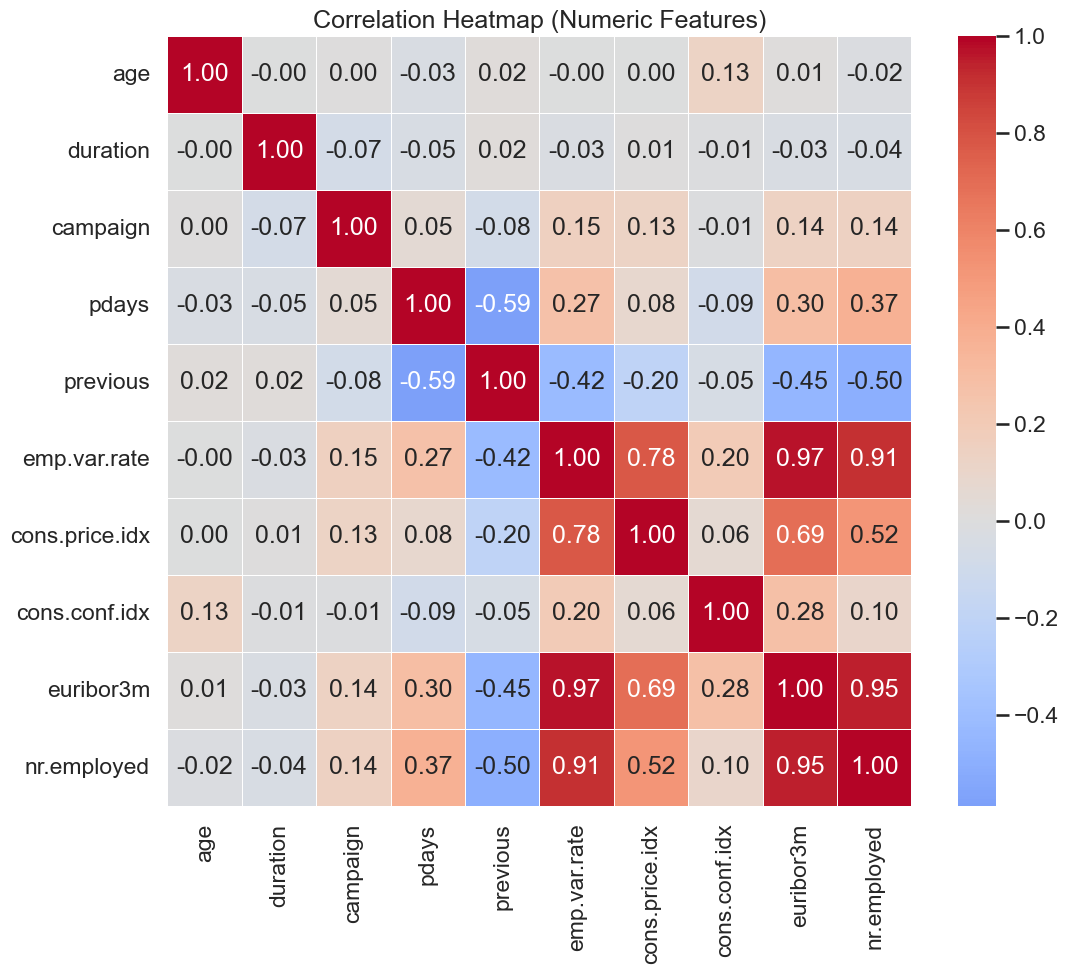

In [13]:

corr = df_clean[numeric_features_raw].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


In [14]:
# Check if any numeric columns are very strongly correlated
corr_mat = df_clean.select_dtypes(include=[np.number]).corr()

threshold = 0.8  # correlation strength cutoff
high_corr_pairs = []

for i, col1 in enumerate(corr_mat.columns):
    for j, col2 in enumerate(corr_mat.columns):
        if i < j:
            r = corr_mat.loc[col1, col2]
            if abs(r) >= threshold:
                high_corr_pairs.append((col1, col2, r))

if high_corr_pairs:
    print("Highly correlated numeric features ( >= 0.8)\n")
    for a, b, r in high_corr_pairs:
        print(f"{a} & {b}: correlation = {r:.2f}")
else:
    print("No strong correlations found among numeric features.")


Highly correlated numeric features ( >= 0.8)

emp.var.rate & euribor3m: correlation = 0.97
emp.var.rate & nr.employed: correlation = 0.91
euribor3m & nr.employed: correlation = 0.95


### Highly Correlated Features

Some numeric features are very strongly related to each other:

- `emp.var.rate` and `euribor3m` (r = 0.97)  
- `emp.var.rate` and `nr.employed` (r = 0.91)  
- `euribor3m` and `nr.employed` (r = 0.95)

This means these columns move almost the same way. When two features give nearly the same information.

## Categorical Feature Impact

In [15]:

def summarize_target_rate(dataframe, column):
    rates = (
        dataframe.groupby(column)["y"]
        .value_counts(normalize=True)
        .rename("ratio")
        .reset_index()
        .pivot(index=column, columns="y", values="ratio")
        .fillna(0)
        .sort_values(by="yes", ascending=False)
    )
    return rates

for col in categorical_features:
    display(summarize_target_rate(df_clean, col).head(10))


y,no,yes
job,,
student,0.685714,0.314286
retired,0.747674,0.252326
unemployed,0.857988,0.142012
admin.,0.870274,0.129726
management,0.887825,0.112175
technician,0.891740,0.108260
self-employed,0.895144,0.104856
housemaid,0.900000,0.100000
entrepreneur,0.914835,0.085165


y,no,yes
marital,,
single,0.859959,0.140041
divorced,0.896791,0.103209
married,0.898427,0.101573


y,no,yes
education,,
illiterate,0.777778,0.222222
university.degree,0.862755,0.137245
professional.course,0.886515,0.113485
high.school,0.891645,0.108355
basic.4y,0.897510,0.102490
basic.6y,0.917976,0.082024
basic.9y,0.921754,0.078246


y,no,yes
default,,
no,0.87121,0.12879
yes,1.00000,0.00000


y,no,yes
housing,,
yes,0.883806,0.116194
no,0.891204,0.108796


y,no,yes
loan,,
no,0.886598,0.113402
yes,0.890685,0.109315


y,no,yes
contact,,
cellular,0.852624,0.147376
telephone,0.947687,0.052313


y,no,yes
month,,
mar,0.494505,0.505495
dec,0.510989,0.489011
sep,0.550877,0.449123
oct,0.561281,0.438719
apr,0.795213,0.204787
aug,0.893979,0.106021
jun,0.894885,0.105115
nov,0.898561,0.101439
jul,0.909534,0.090466


y,no,yes
day_of_week,,
thu,0.878812,0.121188
tue,0.882200,0.117800
wed,0.883329,0.116671
fri,0.891913,0.108087
mon,0.900517,0.099483


y,no,yes
poutcome,,
success,0.348871,0.651129
failure,0.857714,0.142286
nonexistent,0.911678,0.088322


**Key Insights:**
- Students and retirees are the groups most likely to subscribe.
- Managers and housemaids are least likely to subscribe.
- Clients with credit default="yes" have 0% subcription rate.


## Build Preprocessing Pipeline

In [16]:

leakage_columns = [col for col in ["duration"] if col in df_clean.columns]

X = df_clean.drop(columns=["y"])
X_model = X.drop(columns=leakage_columns)
y = df_clean["y"].map({"no": 0, "yes": 1})

numeric_features = X_model.select_dtypes(include="number").columns.tolist()
categorical_features_model = X_model.select_dtypes(include="object").columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features_model),
    ]
)

X_processed_array = preprocessor.fit_transform(X_model)
feature_names = preprocessor.get_feature_names_out()
X_processed = pd.DataFrame(X_processed_array, columns=feature_names, index=df_clean.index)
processed_df = X_processed.assign(y=y.values)
processed_df.head()



,num__age,num__campaign,num__pdays,num__previous,num__emp.var.rate,num__cons.price.idx,num__cons.conf.idx,num__euribor3m,num__nr.employed,cat__job_admin.,...,cat__month_sep,cat__day_of_week_fri,cat__day_of_week_mon,cat__day_of_week_thu,cat__day_of_week_tue,cat__day_of_week_wed,cat__poutcome_failure,cat__poutcome_nonexistent,cat__poutcome_success,y
0,1.533034,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
1,1.628993,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,-0.290186,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
3,-0.002309,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
4,1.533034,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0


## Save Processed Dataset

In [17]:

processed_path = PROCESSED_DIR / "bank_marketing_preprocessed.csv"
processed_df.to_csv(processed_path, index=False)
processed_path


PosixPath('/Users/janmeet/Desktop/SFU/FALL 2025/CMPT 459/Project/fall2025_cmpt459_d1_group7/data/processed/bank_marketing_preprocessed.csv')

## Dimensionality Reduction Snapshot

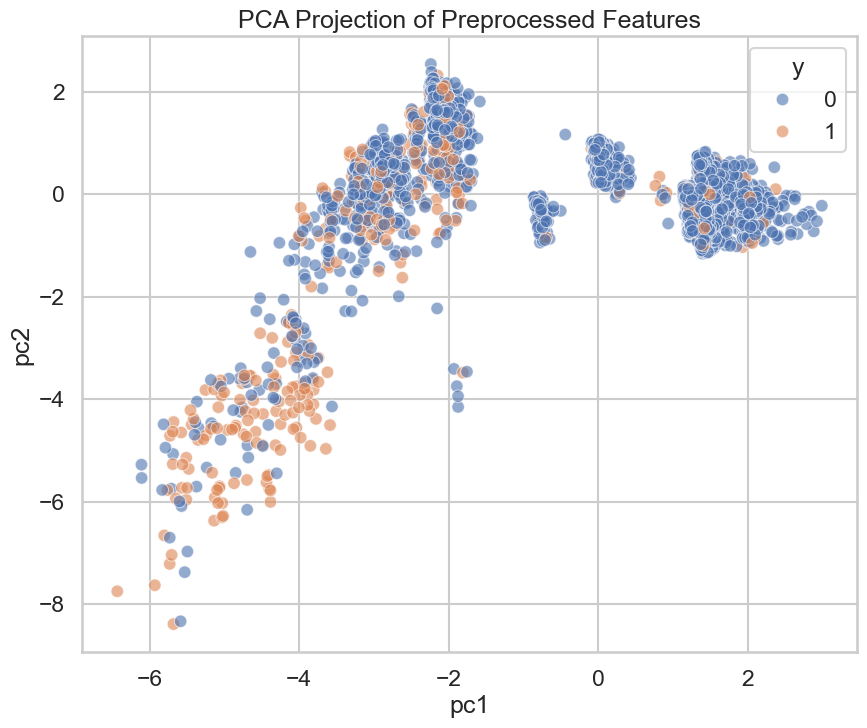

In [18]:

pca = PCA(n_components=2, random_state=42)
embedding = pca.fit_transform(X_processed)
embedding_df = pd.DataFrame(embedding, columns=["pc1", "pc2"]).assign(y=y.values)

plot_sample = embedding_df.sample(n=5000, random_state=42) if len(embedding_df) > 5000 else embedding_df

plt.figure(figsize=(10, 8))
sns.scatterplot(data=plot_sample, x="pc1", y="pc2", hue="y", alpha=0.6, palette="deep")
plt.title("PCA Projection of Preprocessed Features")
plt.show()


**Key Insights:**
- PC1 and PC2 are linear combinations of all numeric and encoded categorical features.
- Each dot represents one customer and the blue and orange colours are the target classes.
- Separable regions means that features contain some patterns distinguishing the two outcomes.

## Explained Variance Curve

[0.2882048  0.38887127 0.4705911  0.54087458 0.60516368 0.65413823
 0.68852829 0.72143449 0.74906092 0.77027208 0.78924094 0.80759816
 0.82557845 0.84172376 0.85632867 0.87045429 0.88427872 0.89786243
 0.91040929 0.92075501 0.93012399 0.93867475 0.9467956  0.95321355
 0.95901085 0.96417984 0.96889053 0.97355468 0.97727004 0.98058599
 0.98357437 0.98610498 0.98854266 0.99082651 0.99271213 0.99441866
 0.99576738 0.99699585 0.998085   0.99895877 0.99929212 0.99959524
 0.9998442  0.99995398 0.99998977 1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.        ]


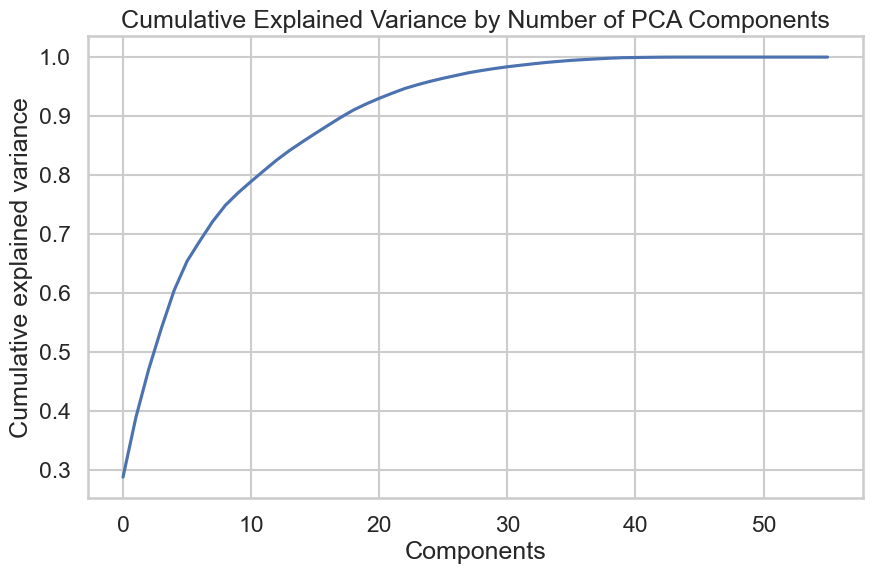

In [19]:
print(PCA().fit(X_processed).explained_variance_ratio_.cumsum())
plt.plot(np.cumsum(PCA().fit(X_processed).explained_variance_ratio_))
plt.xlabel('Components')
plt.ylabel('Cumulative explained variance')
plt.title("Cumulative Explained Variance by Number of PCA Components")
plt.show()


**Key Insights:**
- Keeping 20-30 components would preserve over 90-95% of the information.

## Data Augmentation

In [20]:
X = processed_df.drop(columns=["y"])
y = processed_df["y"]
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)
print("Before SMOTE:", df_clean["y"].value_counts())
print("After SMOTE:", y_res.value_counts())

Before SMOTE: y
no     36548
yes     4640
Name: count, dtype: int64
After SMOTE: y
0    36548
1    36548
Name: count, dtype: int64


**Key Insights:**
- The dataset is highly imbalanced with 36,548 "no" and 4,640 "yes" samples.
- The imbalance can bias classfication models toward the majority class.
- SMOTE (Synthetic Minority Oversampling Technique) was applied to generate synthetic minority samples resulting in balanced dataset.

## Dimentionality Reduction after Data Augmentation

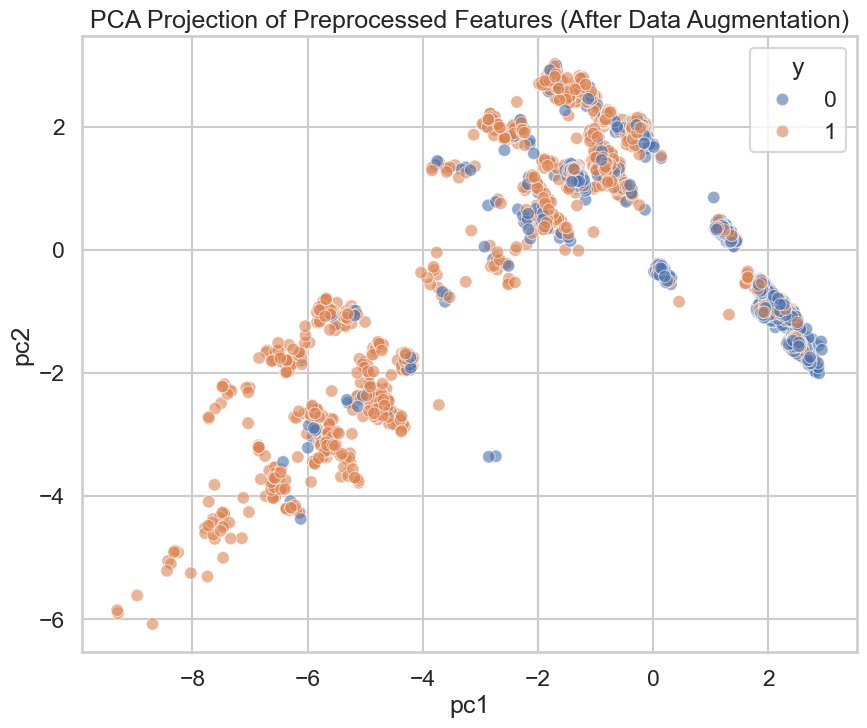

In [21]:
pca_aug = PCA(n_components=2, random_state=42)
embedding_aug = pca_aug.fit_transform(X_res)
embedding_df_aug = pd.DataFrame(embedding_aug, columns=["pc1", "pc2"]).assign(y=y_res.values)

plot_sample = embedding_df_aug.sample(n=5000, random_state=42) if len(embedding_df_aug) > 5000 else embedding_df_aug

plt.figure(figsize=(10, 8))
sns.scatterplot(data=plot_sample, x="pc1", y="pc2", hue="y", alpha=0.6, palette="deep")
plt.title("PCA Projection of Preprocessed Features (After Data Augmentation)")
plt.show()

**Key Insights:**
- Before Data Augmentation, the PCA projection showed imbalanced distribution with the majority class dominating the feature space. 
- After applying SMOTE, the class distribution is balanced, and the PCA projection shows a more uniform spread of the minority class.